In [21]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy import stats
from scipy.signal import medfilt

# Загрузка данных
titanic = sns.load_dataset('titanic')
print("Первые 5 строк данных:")
print(titanic.head())

# Анализ структуры данных
print("\nИнформация о данных:")
print(titanic.info())

# Статистика по числовым столбцам
print("\nОписательная статистика:")
print(titanic.describe())

# Проверка пропущенных значений
print("\nПропущенные значения:")
print(titanic.isnull().sum())

Первые 5 строк данных:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------

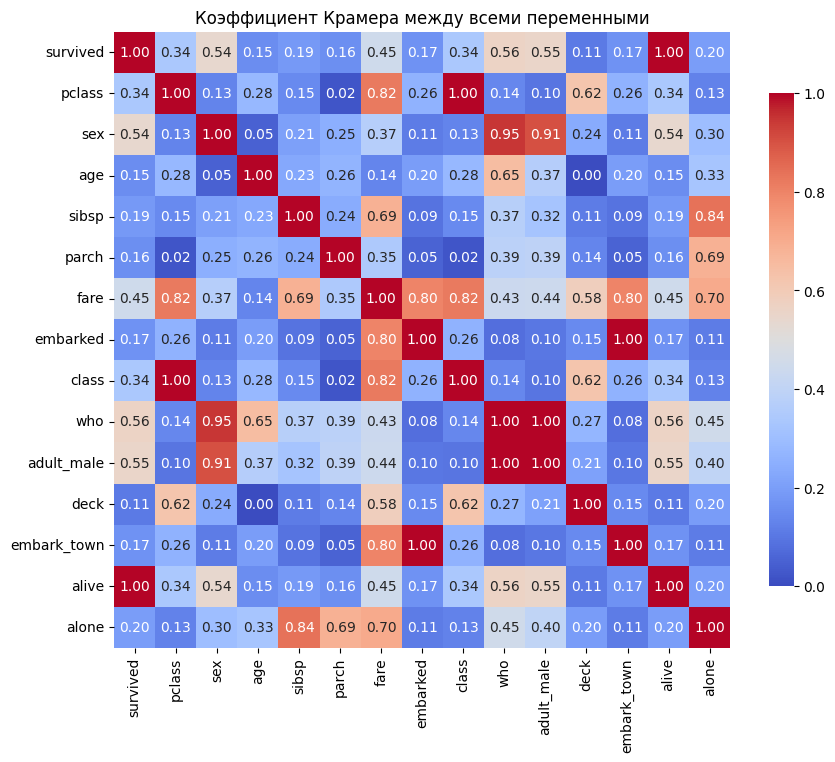

In [23]:
from scipy.stats import chi2_contingency

cols = titanic.columns.tolist()

# Функция для вычисления коэффициента Крамера
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - (k - 1) * (r - 1) / (n - 1))
    rcorr = r - 1
    kcorr = k - 1
    return np.sqrt(phi2corr / min((kcorr, rcorr)))

# Создайте DataFrame для хранения значений коэффициента Крамера
cramers_v_matrix = pd.DataFrame(index=cols, columns=cols)

# Вычислите коэффициент Крамера для каждой пары категориальных переменных
for i in range(len(cols)):
    for j in range(len(cols)):
        if i != j:
            cramers_v_matrix.iloc[i, j] = cramers_v(titanic[cols[i]], titanic[cols[j]])
        else:
            cramers_v_matrix.iloc[i, j] = 1.0  # Корреляция с самой собой

# Преобразуйте в числовой формат
cramers_v_matrix = cramers_v_matrix.astype(float)

# Визуализация матрицы корреляции
plt.figure(figsize=(10, 8))
sns.heatmap(cramers_v_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title("Коэффициент Крамера между всеми переменными")
plt.show()


In [2]:
# Выберем признаки и целевую переменную
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
target = 'survived'

# Преобразуем категориальные признаки
data = titanic[features + [target]].copy()
data['sex'] = data['sex'].map({'male': 0, 'female': 1})
data['embarked'] = data['embarked'].map({'S': 0, 'C': 1, 'Q': 2, None: np.nan})

# Разделение на признаки и целевую переменную
X = data[features]
y = data[target]

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Функция для масштабирования данных
def scale_data(X_train, X_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

# Базовая модель без обработки пропусков (удаляем строки с NaN)
X_train_base = X_train.dropna()
y_train_base = y_train[X_train.index.isin(X_train_base.index)]
X_test_base = X_test.dropna()
y_test_base = y_test[X_test.index.isin(X_test_base.index)]

X_train_base_scaled, X_test_base_scaled = scale_data(X_train_base, X_test_base)

In [3]:
def create_model(input_shape):
    model = keras.Sequential([
        keras.layers.Dense(64, activation='relu', input_shape=(input_shape,)),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Функция для обучения модели и записи истории
def train_and_evaluate(model, X_train, y_train, X_test, y_test, epochs=20):
    history = model.fit(X_train, y_train, 
                        epochs=epochs, 
                        validation_data=(X_test, y_test),
                        verbose=0)
    return history

# Создаем и обучаем базовую модель
base_model = create_model(X_train_base_scaled.shape[1])
base_history = train_and_evaluate(base_model, 
                                 X_train_base_scaled, 
                                 y_train_base, 
                                 X_test_base_scaled, 
                                 y_test_base)

C:\Dev\Jupyter\dist\pyenv3.12.7-win64\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
# Заполнение пропущенных значений средним
X_train_mean = X_train.copy()
X_test_mean = X_test.copy()

for column in ['age', 'fare']:
    X_train_mean[column].fillna(X_train_mean[column].mean(), inplace=True)
    X_test_mean[column].fillna(X_train_mean[column].mean(), inplace=True)

# Для embarked заполним модой
embarked_mode = X_train_mean['embarked'].mode()[0]
X_train_mean['embarked'].fillna(embarked_mode, inplace=True)
X_test_mean['embarked'].fillna(embarked_mode, inplace=True)

# Масштабирование
X_train_mean_scaled, X_test_mean_scaled = scale_data(X_train_mean, X_test_mean)

# Обучение модели на данных с заполненными пропусками
mean_model = create_model(X_train_mean_scaled.shape[1])
mean_history = train_and_evaluate(mean_model, 
                                X_train_mean_scaled, 
                                y_train, 
                                X_test_mean_scaled, 
                                y_test)

C:\Users\PC\AppData\Local\Temp\ipykernel_16724\911262471.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train_mean[column].fillna(X_train_mean[column].mean(), inplace=True)
C:\Users\PC\AppData\Local\Temp\ipykernel_16724\911262471.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

In [31]:
# Функция для удаления выбросов на основе Z-оценки
def remove_outliers_zscore(X, y, threshold=3):
    z_scores = np.abs(stats.zscore(X.select_dtypes(include=['float64', 'int64'])))
    outliers = (z_scores > threshold).any(axis=1)
    return X[~outliers], y[~outliers]

# Удаление выбросов
X_train_no_outliers, y_train_no_outliers = remove_outliers_zscore(X_train_mean, y_train)
X_test_no_outliers, y_test_no_outliers = remove_outliers_zscore(X_test_mean, y_test)

# Масштабирование
X_train_no_outliers_scaled, X_test_no_outliers_scaled = scale_data(X_train_no_outliers, X_test_no_outliers)

# Обучение модели на данных без выбросов
no_outliers_model = create_model(X_train_no_outliers_scaled.shape[1])
no_outliers_history = train_and_evaluate(no_outliers_model, 
                                       X_train_no_outliers_scaled, 
                                       y_train_no_outliers, 
                                       X_test_no_outliers_scaled, 
                                       y_test_no_outliers)

C:\Dev\Jupyter\dist\pyenv3.12.7-win64\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
# Применение медианного фильтра к числовым признакам
def apply_median_filter(X, kernel_size=3):
    X_filtered = X.copy()
    for column in X_filtered.select_dtypes(include=['float64', 'int64']):
        X_filtered[column] = medfilt(X_filtered[column], kernel_size=kernel_size)
    return X_filtered

# Фильтрация шума
X_train_filtered = apply_median_filter(X_train_no_outliers)
X_test_filtered = apply_median_filter(X_test_no_outliers)

# Масштабирование
X_train_filtered_scaled, X_test_filtered_scaled = scale_data(X_train_filtered, X_test_filtered)

# Обучение модели на отфильтрованных данных
filtered_model = create_model(X_train_filtered_scaled.shape[1])
filtered_history = train_and_evaluate(filtered_model, 
                                    X_train_filtered_scaled, 
                                    y_train_no_outliers, 
                                    X_test_filtered_scaled, 
                                    y_test_no_outliers)

C:\Dev\Jupyter\dist\pyenv3.12.7-win64\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


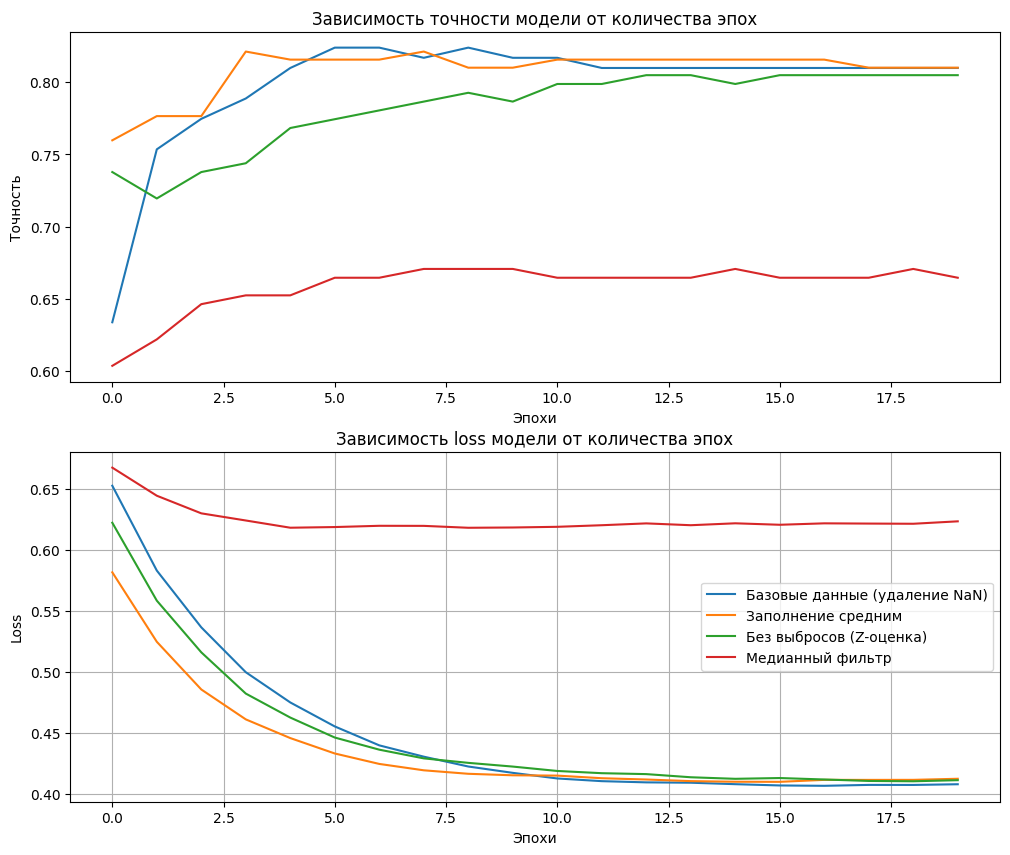

In [36]:
# Построение графиков точности
plt.figure(figsize=(12, 10))
plt.subplot(2,1,1)
plt.plot(base_history.history['val_accuracy'], label='Базовые данные (удаление NaN)')
plt.plot(mean_history.history['val_accuracy'], label='Заполнение средним')
plt.plot(no_outliers_history.history['val_accuracy'], label='Без выбросов (Z-оценка)')
plt.plot(filtered_history.history['val_accuracy'], label='Медианный фильтр')
plt.title('Зависимость точности модели от количества эпох')
plt.xlabel('Эпохи')
plt.ylabel('Точность')


plt.subplot(2,1,2)
plt.plot(base_history.history['val_loss'], label='Базовые данные (удаление NaN)')
plt.plot(mean_history.history['val_loss'], label='Заполнение средним')
plt.plot(no_outliers_history.history['val_loss'], label='Без выбросов (Z-оценка)')
plt.plot(filtered_history.history['val_loss'], label='Медианный фильтр')
plt.title('Зависимость loss модели от количества эпох')
plt.xlabel('Эпохи')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
[[93  0]
 [71  0]]


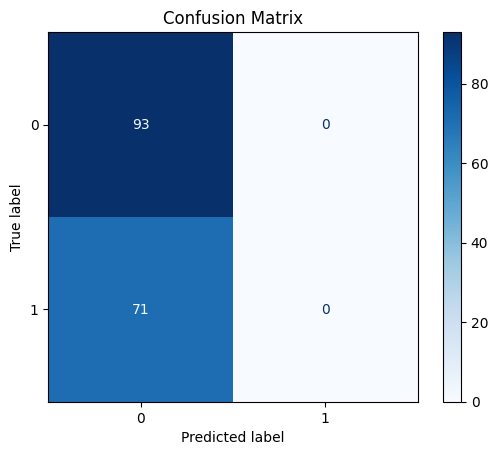

In [34]:
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, auc, ConfusionMatrixDisplay
y_score = filtered_model.predict(X_test_filtered_scaled)

y_pred = np.argmax(y_score, axis=1)
y_true = np.argmax(X_test_filtered_scaled, axis=1)

cm = confusion_matrix(y_test_no_outliers, y_pred)
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix');